In [1]:
from pathlib import Path

import random

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import models
from torchvision import transforms

from sklearn.metrics import (
    roc_curve,
    auc
)

from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial.distance import euclidean

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

CHANGE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "change_detection"
)

CHANGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(DEVICE)

cuda


In [4]:
metadata_df = pd.read_csv(

    PROCESSED_DIR
    / "eurosat_geo_clusters.csv"

)

print(metadata_df.shape)

metadata_df.head()

(27000, 7)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon,class_id,geo_cluster
0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,44.035220,28.559055,0,3
1,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,39.085801,-1.829726,0,5
2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,48.977295,4.239720,0,2
3,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,48.892610,4.089878,0,2
4,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,AnnualCrop,51.832851,18.084960,0,6


In [5]:
eval_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [6]:
resnet18 = models.resnet18(

    weights=None

)

resnet18.fc = nn.Linear(

    resnet18.fc.in_features,

    10

)

resnet18.load_state_dict(

    torch.load(

        CHECKPOINT_DIR
        / "resnet18_finetuned_best.pt",

        map_location=DEVICE

    )

)

resnet18 = resnet18.to(DEVICE)

resnet18.eval()

print("Checkpoint Loaded")

Checkpoint Loaded


In [7]:
feature_extractor = nn.Sequential(

    *list(resnet18.children())[:-1]

)

feature_extractor.eval()

feature_extractor.to(DEVICE)

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [8]:
def extract_embedding(image_path):

    image = Image.open(

        image_path

    ).convert("RGB")

    image = eval_transform(image)

    image = image.unsqueeze(0)

    image = image.to(DEVICE)

    with torch.no_grad():

        embedding = feature_extractor(

            image

        )

    embedding = embedding.squeeze()

    embedding = embedding.cpu().numpy()

    return embedding

In [9]:
sample_path = metadata_df.iloc[0]["filepath_rgb"]

embedding = extract_embedding(sample_path)

print(embedding.shape)

(512,)


In [10]:
cluster_groups = {}

for cluster in sorted(metadata_df["geo_cluster"].unique()):

    cluster_groups[cluster] = metadata_df[
        metadata_df["geo_cluster"] == cluster
    ].reset_index(drop=True)

print(cluster_groups.keys())

dict_keys([np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)])


In [11]:
pairs = []

random.seed(42)

NUM_PAIRS_PER_CLUSTER = 100

for cluster, cluster_df in cluster_groups.items():

    classes = cluster_df["class_name"].unique()

    # ---------- Unchanged ----------

    for cls in classes:

        cls_df = cluster_df[
            cluster_df["class_name"] == cls
        ]

        if len(cls_df) < 2:
            continue

        n_pairs = min(
            NUM_PAIRS_PER_CLUSTER,
            len(cls_df) // 2
        )

        for _ in range(n_pairs):

            idx1, idx2 = random.sample(
                range(len(cls_df)),
                2
            )

            pairs.append({

                "geo_cluster": cluster,

                "t1": cls_df.iloc[idx1]["filepath_rgb"],

                "t2": cls_df.iloc[idx2]["filepath_rgb"],

                "label": 0

            })

    # ---------- Changed ----------

    if len(classes) < 2:
        continue

    for _ in range(NUM_PAIRS_PER_CLUSTER):

        cls1, cls2 = random.sample(
            list(classes),
            2
        )

        df1 = cluster_df[
            cluster_df["class_name"] == cls1
        ]

        df2 = cluster_df[
            cluster_df["class_name"] == cls2
        ]

        row1 = df1.sample(
            n=1,
            random_state=random.randint(0,100000)
        ).iloc[0]

        row2 = df2.sample(
            n=1,
            random_state=random.randint(0,100000)
        ).iloc[0]

        pairs.append({

            "geo_cluster": cluster,

            "t1": row1["filepath_rgb"],

            "t2": row2["filepath_rgb"],

            "label": 1

        })

In [12]:
pairs_df = pd.DataFrame(pairs)

print(pairs_df.shape)

pairs_df.head()

(5580, 4)


,geo_cluster,t1,t2,label
0,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0
1,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0
2,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0
3,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0
4,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0


In [13]:
changed_df = pairs_df[
    pairs_df["label"] == 1
]

unchanged_df = pairs_df[
    pairs_df["label"] == 0
].sample(
    n=len(changed_df),
    random_state=42
)

pairs_df = pd.concat(
    [
        changed_df,
        unchanged_df
    ],
    ignore_index=True
)

pairs_df = pairs_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(pairs_df["label"].value_counts())
print(pairs_df.shape)

label
0    600
1    600
Name: count, dtype: int64
(1200, 4)


In [14]:
pairs_df["label"].value_counts()

label
0    600
1    600
Name: count, dtype: int64

In [15]:
pair_csv = (
    CHANGE_DIR
    / "change_detection_pairs.csv"
)

pairs_df.to_csv(
    pair_csv,
    index=False
)

print(pair_csv)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\change_detection\change_detection_pairs.csv


In [16]:
results = []

for _, row in pairs_df.iterrows():

    emb1 = extract_embedding(
        row["t1"]
    )

    emb2 = extract_embedding(
        row["t2"]
    )

    cosine = cosine_similarity(
        emb1.reshape(1, -1),
        emb2.reshape(1, -1)
    )[0][0]

    distance = euclidean(
        emb1,
        emb2
    )

    results.append({

        "geo_cluster": row["geo_cluster"],

        "t1": row["t1"],

        "t2": row["t2"],

        "label": row["label"],

        "cosine_similarity": cosine,

        "euclidean_distance": distance

    })

In [17]:
results_df = pd.DataFrame(results)

print(results_df.shape)

results_df.head()

(1200, 6)


,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance
0,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.952261,9.710373
1,2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.933958,8.595058
2,2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.527036,28.852236
3,5,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.479947,25.977468
4,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.560049,24.459927


In [18]:
results_df.groupby("label")[
    [
        "cosine_similarity",
        "euclidean_distance"
    ]
].describe()

cosine_similarity                                                    \
                  count      mean       std       min       25%       50%   
label                                                                       
0                 600.0  0.802624  0.087087  0.502315  0.750505  0.811700   
1                 600.0  0.591491  0.098002  0.379373  0.520895  0.583743   

                          euclidean_distance                                  \
            75%       max              count       mean       std        min   
label                                                                          
0      0.859420  0.995796              600.0  16.889100  4.493154   3.077443   
1      0.665919  0.840561              600.0  24.715425  4.458825  12.919779   

                                                   
             25%        50%        75%        max  
label                                              
0      14.396015  17.049422  19.765452  29.129370  
1      21.520825  24.878241  27.893296  37.642307

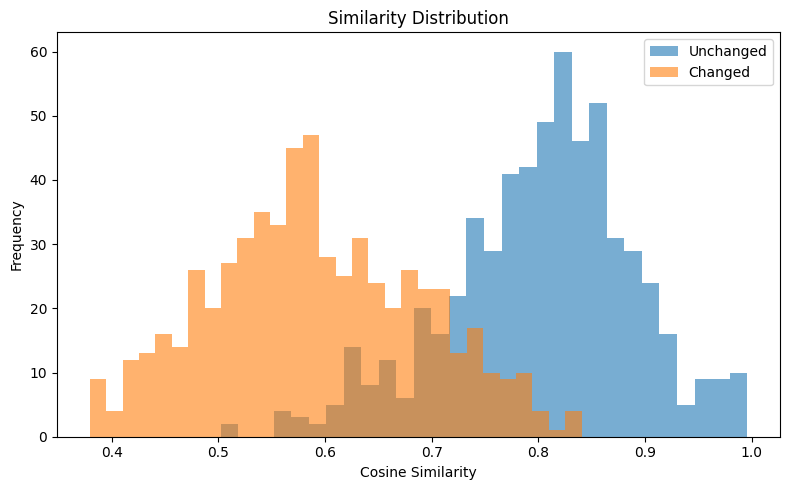

In [19]:
plt.figure(figsize=(8,5))

plt.hist(

    results_df[
        results_df["label"] == 0
    ]["cosine_similarity"],

    bins=30,

    alpha=0.6,

    label="Unchanged"

)

plt.hist(

    results_df[
        results_df["label"] == 1
    ]["cosine_similarity"],

    bins=30,

    alpha=0.6,

    label="Changed"

)

plt.xlabel("Cosine Similarity")

plt.ylabel("Frequency")

plt.title("Similarity Distribution")

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
fpr, tpr, thresholds = roc_curve(

    results_df["label"],

    -results_df["cosine_similarity"]

)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC: {roc_auc:.4f}")

AUC: 0.9407


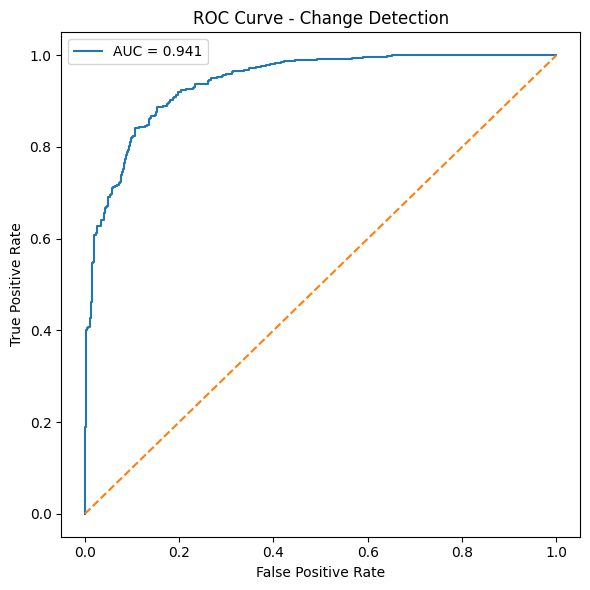

In [21]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Change Detection")

plt.legend()

plt.tight_layout()

plt.savefig(
    CHANGE_DIR /
    "roc_curve.png",
    dpi=300
)

plt.show()

In [22]:
j_scores = tpr - fpr

best_idx = j_scores.argmax()

best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")

print(f"TPR: {tpr[best_idx]:.4f}")

print(f"FPR: {fpr[best_idx]:.4f}")

Best Threshold: -0.6941
TPR: 0.8417
FPR: 0.1067


In [23]:
SIMILARITY_THRESHOLD = 0.7274

results_df["prediction"] = (
    results_df["cosine_similarity"]
    < SIMILARITY_THRESHOLD
).astype(int)

results_df.head()

,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance,prediction
0,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.952261,9.710373,0
1,2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.933958,8.595058,0
2,2,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.527036,28.852236,1
3,5,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.479947,25.977468,1
4,0,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.560049,24.459927,1


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(
        results_df["label"],
        results_df["prediction"]
    )
)

print()

print(
    classification_report(
        results_df["label"],
        results_df["prediction"],
        target_names=[
            "Unchanged",
            "Changed"
        ]
    )
)

Accuracy: 0.8616666666666667

              precision    recall  f1-score   support

   Unchanged       0.89      0.82      0.86       600
     Changed       0.83      0.90      0.87       600

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200



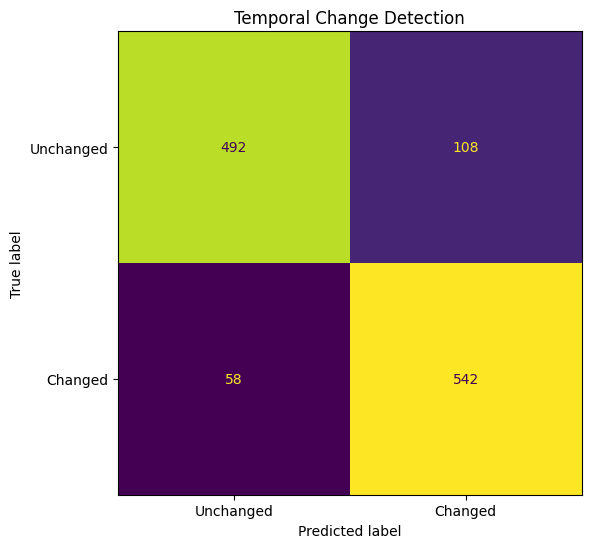

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    results_df["label"],
    results_df["prediction"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Unchanged",
        "Changed"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    colorbar=False
)

plt.title("Temporal Change Detection")

plt.tight_layout()

plt.savefig(
    CHANGE_DIR /
    "change_detection_confusion_matrix.png",
    dpi=300
)

plt.show()

In [26]:
metrics_df = pd.DataFrame({

    "Metric": [
        "AUC",
        "Threshold",
        "Accuracy",
        "TPR",
        "FPR"
    ],

    "Value": [
        roc_auc,
        SIMILARITY_THRESHOLD,
        accuracy_score(
            results_df["label"],
            results_df["prediction"]
        ),
        tpr[best_idx],
        fpr[best_idx]
    ]

})

metrics_df.to_csv(
    CHANGE_DIR / "change_detection_metrics.csv",
    index=False
)

In [27]:
correct_unchanged = results_df[
    (results_df["label"] == 0) &
    (results_df["prediction"] == 0)
].sample(
    2,
    random_state=42
)

correct_changed = results_df[
    (results_df["label"] == 1) &
    (results_df["prediction"] == 1)
].sample(
    2,
    random_state=42
)

misclassified = results_df[
    results_df["label"] !=
    results_df["prediction"]
].sample(
    1,
    random_state=42
)

examples = pd.concat(
    [
        correct_unchanged,
        correct_changed,
        misclassified
    ],
    ignore_index=True
)

examples

,geo_cluster,t1,t2,label,cosine_similarity,euclidean_distance,prediction
0,3,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.910785,9.552161,0
1,4,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,0,0.825266,23.259970,0
2,3,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.706162,20.647650,1
3,5,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.489849,31.637207,1
4,3,c:\Users\ASUS\dev\projects\satellite-project-c...,c:\Users\ASUS\dev\projects\satellite-project-c...,1,0.754422,15.519946,0


In [28]:
def visualize_change_pair(row, save_index):

    img1 = Image.open(
        row["t1"]
    ).convert("RGB")

    img2 = Image.open(
        row["t2"]
    ).convert("RGB")

    img1_np = np.array(img1)
    img2_np = np.array(img2)

    diff = np.abs(
        img1_np.astype(np.float32)
        -
        img2_np.astype(np.float32)
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15,5)
    )

    axes[0].imshow(img1)
    axes[0].set_title("T1")
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title("T2")
    axes[1].axis("off")

    axes[2].imshow(
        diff.astype(np.uint8)
    )
    axes[2].set_title("Absolute Difference")
    axes[2].axis("off")

    plt.suptitle(

        f"Cluster: {row['geo_cluster']} | "

        f"Similarity: {row['cosine_similarity']:.3f}\n"

        f"Ground Truth: {'Changed' if row['label'] else 'Unchanged'} | "

        f"Prediction: {'Changed' if row['prediction'] else 'Unchanged'}"

    )

    plt.tight_layout()

    plt.savefig(

        CHANGE_DIR /

        f"change_heatmap_{save_index}.png",

        dpi=300

    )

    plt.show()

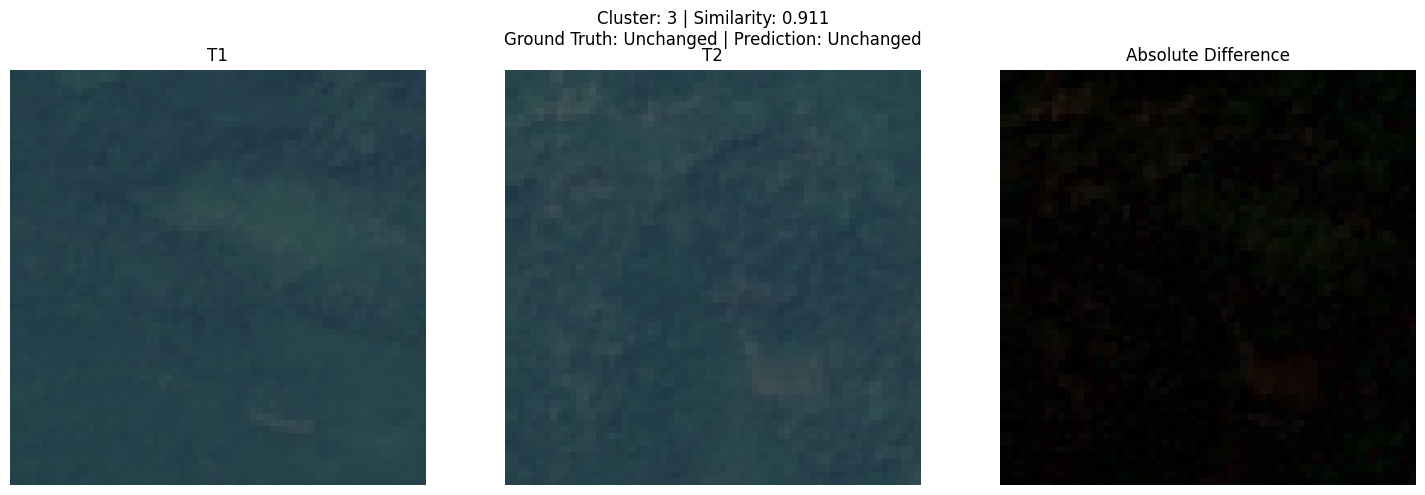

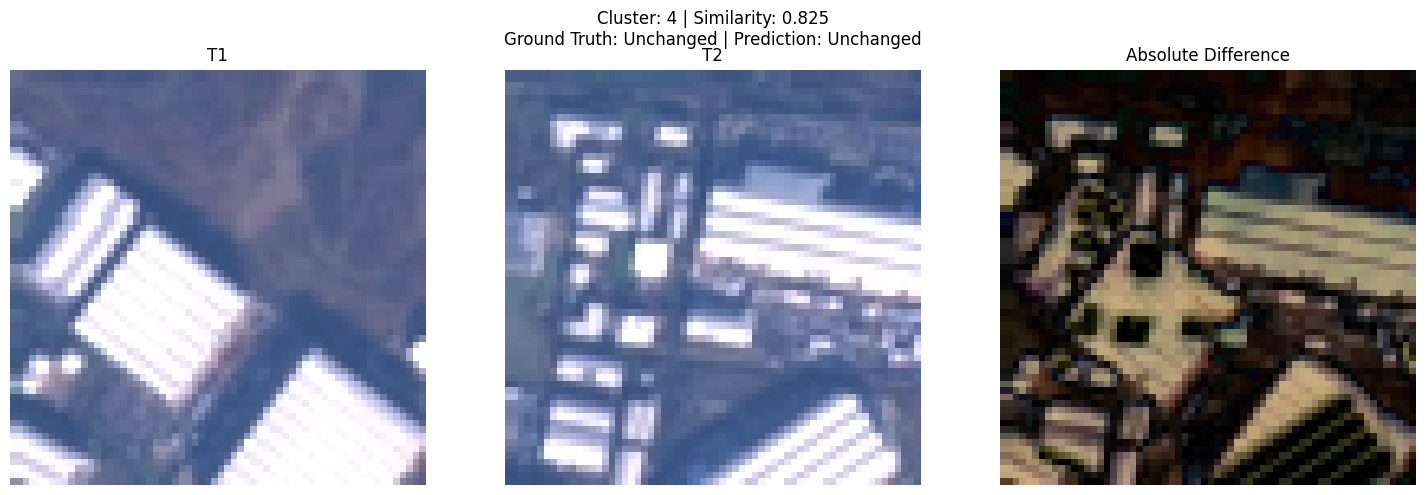

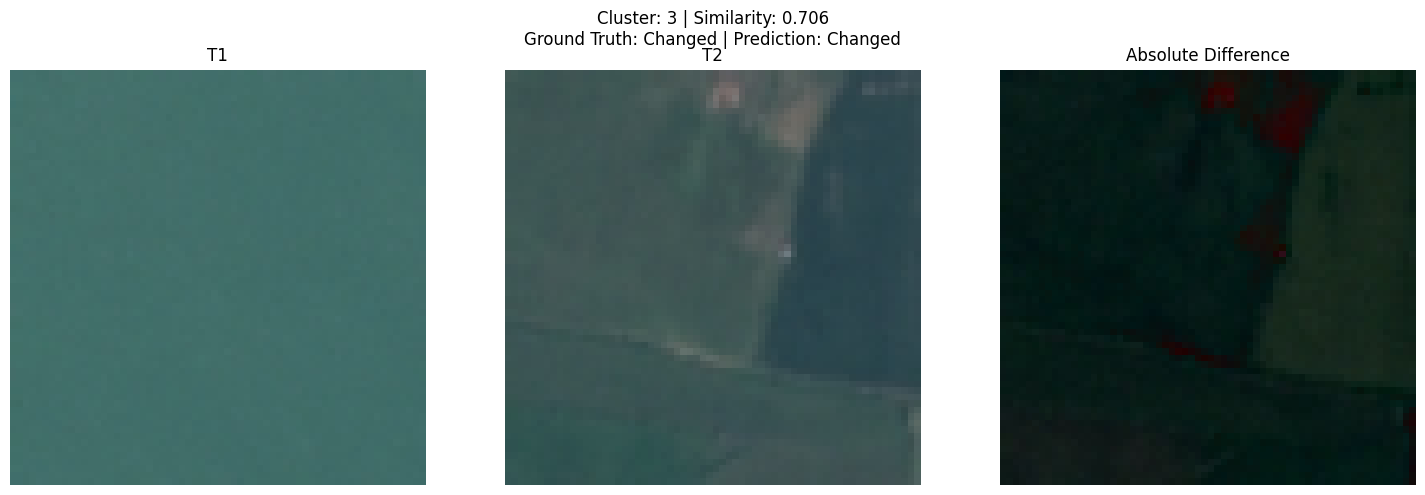

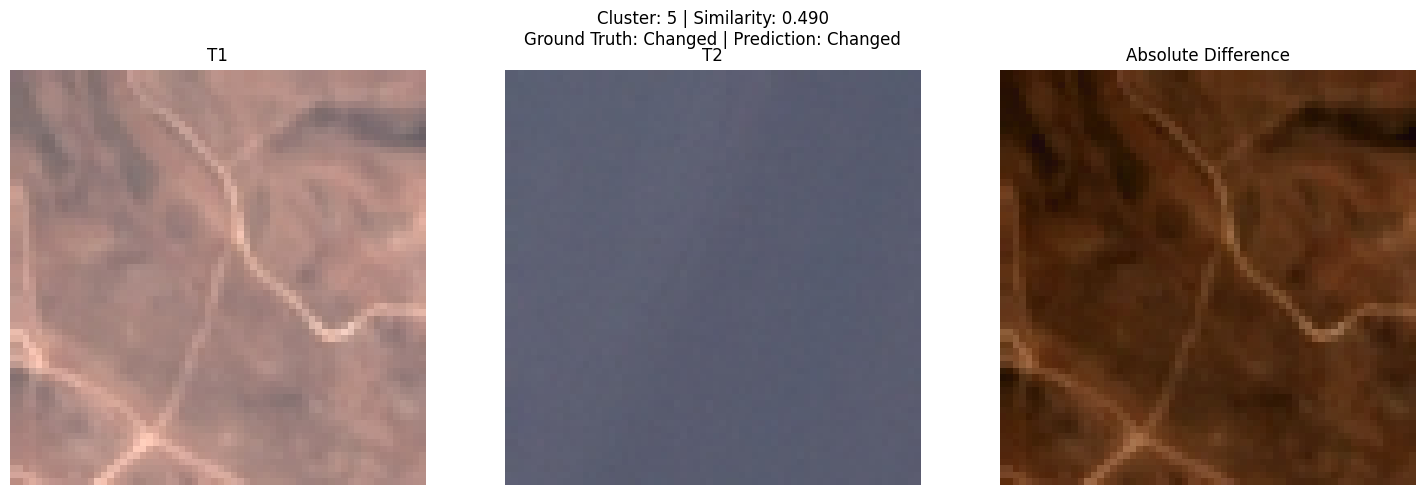

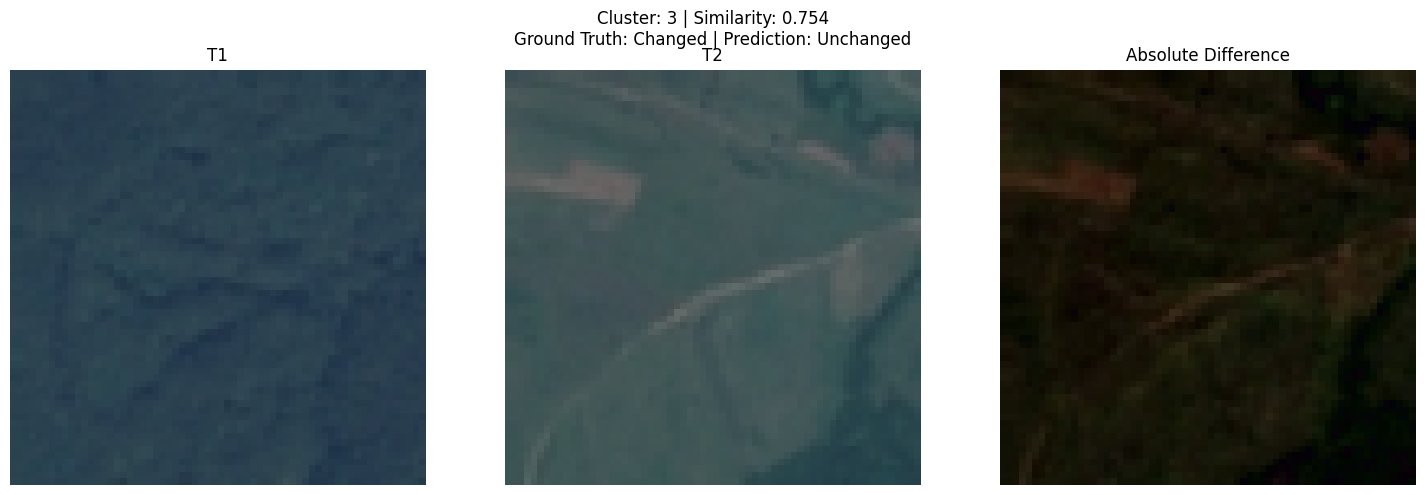

In [29]:
for idx, row in examples.iterrows():

    visualize_change_pair(
        row,
        idx + 1
    )

In [30]:
examples.to_csv(

    CHANGE_DIR /
    "selected_change_examples.csv",

    index=False

)

print("Saved selected examples.")

Saved selected examples.
